In [ ]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Set up seaborn styling
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Try to use seaborn style, fallback to default if not available
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')

# Define color palettes
NEURAL_COLORS = sns.color_palette("viridis", 12)  # For neural channels
BEHAVIORAL_COLORS = sns.color_palette("Set2", 3)  # For behavioral data
FILTER_COLORS = {"raw": "#CCCCCC", "filtered": "#6B46C1"}  # Raw vs filtered

# =============================================================================
# CONFIGURATION PARAMETERS - Modify these to explore different settings
# =============================================================================

# File path
h5_file_path = r"D:\Data\ScienceCorp\trials_aligned.h5"

# Trial selection
TRIAL_NUMBER = 112  # Which trial to analyze

# Channel selection
USE_SPIKE_CHANNELS_ONLY = True  # Use only manually identified spike channels
N_CHANNELS = 10  # Number of channels to plot (ignored if USE_SPIKE_CHANNELS_ONLY=True)

# Manually identified channels with spike activity (from manual inspection)
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

# Neural filter parameters (bandpass filter)
FILTER_LOW = 400   # Low cutoff frequency (Hz)
FILTER_HIGH = 6000  # High cutoff frequency (Hz)
FILTER_ORDER = 4   # Filter order

# Sampling rate (from the HDF5 file metadata)
SAMPLING_RATE = 30000  # Hz (downsampled rate)

# Plotting parameters (figure size adapts to number of channels)
FIGURE_WIDTH = 15  # Fixed width
HEIGHT_PER_CHANNEL = 10  # Height allocated per neural channel
BEHAVIORAL_PLOT_HEIGHT = 3.5  # Extra height for behavioral plot at top
RANDOM_SEED = 42  # For reproducible channel selection

# 💡 TIP: Adjust HEIGHT_PER_CHANNEL (1.2-2.5) to make plots more/less compressed
# 💡 TIP: Increase BEHAVIORAL_PLOT_HEIGHT (3-5) for larger behavioral plot

# Calculate dynamic figure size based on number of channels
def calculate_figure_size(n_channels):
    """
    Calculate optimal figure size based on number of channels.
    
    Formula: height = behavioral_plot_height + (n_channels × height_per_channel)
    
    Args:
        n_channels: Number of neural channels to plot
        
    Returns:
        tuple: (width, height) in inches
        
    Examples:
        - 5 channels  → (15, 12.5")
        - 10 channels → (15, 21.5") 
        - 20 channels → (15, 39.5")
    """
    height = BEHAVIORAL_PLOT_HEIGHT + (n_channels * HEIGHT_PER_CHANNEL)
    # Add some padding and ensure minimum/maximum sizes
    height = max(8, min(height, 50))  # Minimum 8", maximum 50"
    return (FIGURE_WIDTH, height)

print("🎛️  Configuration loaded:")
print(f"   📁 Trial: {TRIAL_NUMBER}")
print(f"   🧠 Channels: {N_CHANNELS}")
print(f"   🔧 Filter: {FILTER_LOW}-{FILTER_HIGH} Hz")
print(f"   ⏱️  Sampling rate: {SAMPLING_RATE} Hz")
print(f"   📏 Figure size: {calculate_figure_size(N_CHANNELS)} (width x height)")
print(f"   🎨 Styling: Seaborn enhanced visualization")
print(f"   📊 Features: Synchronized plots + summary statistics")

# =============================================================================

def load_trial_data(h5_file, trial_number):
    """Load all data for a specific trial."""
    trial_key = f'trial_{trial_number}'
    
    if trial_key not in h5_file:
        return None
    
    trial = h5_file[trial_key]
    
    # Load data
    data = {
        'trial_number': trial_number,
        'neural_data': trial['neural'][:] if 'neural' in trial else None,
        'velocity_x': trial['velocity_x'][:] if 'velocity_x' in trial else None,
        'velocity_y': trial['velocity_y'][:] if 'velocity_y' in trial else None,
        'behavioral_timestamps': trial['behavioral_timestamps'][:] if 'behavioral_timestamps' in trial else None,
    }
    
    # Load metadata
    for attr_name in trial.attrs.keys():
        data[attr_name] = trial.attrs[attr_name]
        if isinstance(data[attr_name], bytes):
            data[attr_name] = data[attr_name].decode()
    
    return data

def bandpass_filter(data, low_freq, high_freq, fs, order=4):
    """
    Apply bandpass filter to neural data.
    
    Args:
        data: Neural data array (channels x time)
        low_freq: Low cutoff frequency (Hz)
        high_freq: High cutoff frequency (Hz)
        fs: Sampling rate (Hz)
        order: Filter order
    
    Returns:
        Filtered neural data
    """
    # Design Butterworth bandpass filter
    nyquist = fs / 2
    low = low_freq / nyquist
    high = high_freq / nyquist
    
    # Check if frequencies are valid
    if low <= 0 or high >= 1:
        print(f"⚠️  Warning: Filter frequencies ({low_freq}-{high_freq} Hz) may be outside valid range for fs={fs} Hz")
        low = max(0.01, low)
        high = min(0.99, high)
    
    try:
        b, a = signal.butter(order, [low, high], btype='band')
        
        # Apply filter to each channel
        filtered_data = np.zeros_like(data)
        for ch in range(data.shape[0]):
            filtered_data[ch, :] = signal.filtfilt(b, a, data[ch, :])
        
        return filtered_data
    
    except Exception as e:
        print(f"❌ Filter error: {e}")
        return data  # Return original data if filtering fails

# Load and check the file
print(f"Loading: {h5_file_path}")
if os.path.exists(h5_file_path):
    file_size_mb = os.path.getsize(h5_file_path) / (1024 * 1024)
    print(f"File size: {file_size_mb:.2f} MB")
    
    with h5py.File(h5_file_path, 'r') as f:
        print(f"Total trials: {len(f.keys())}")
        
        # Load the specified trial
        trial_data = load_trial_data(f, TRIAL_NUMBER)
        if trial_data:
            print(f"\n✅ Trial {TRIAL_NUMBER} loaded:")
            print(f"  Neural data shape: {trial_data['neural_data'].shape}")
            print(f"  Behavioral data: {trial_data['velocity_x'].shape if trial_data['velocity_x'] is not None else 'None'}")
            print(f"  Outcome: {trial_data['outcome']}")
            print(f"  Duration: {trial_data['duration']:.2f}s")
        else:
            print(f"❌ Trial {TRIAL_NUMBER} not found!")
else:
    print("❌ File not found!")

🎛️  Configuration loaded:
   📁 Trial: 112
   🧠 Channels: 96
   🔧 Filter: 400-6000 Hz
   ⏱️  Sampling rate: 30000 Hz
   📏 Figure size: (15, 50) (width x height)
   🎨 Styling: Seaborn enhanced visualization
   📊 Features: Synchronized plots + summary statistics
Loading: D:\Data\ScienceCorp\trials_aligned.h5
File size: 1487.95 MB
Total trials: 140

✅ Trial 112 loaded:
  Neural data shape: (96, 78625)
  Behavioral data: (94,)
  Outcome: win
  Duration: 2.42s


🎨 Creating synchronized visualization for trial 112...
📊 Data shapes:
   Neural: (96, 78625) (channels × time)
   Velocity: (94,) samples
🔧 Applying bandpass filter (400-6000 Hz)...
🧠 Selected channels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95]
⏱️  Time alignment: Neural 2.42s, Behavioral 2.42s
📏 Creating figure with size: (15, 50) for 96 channels


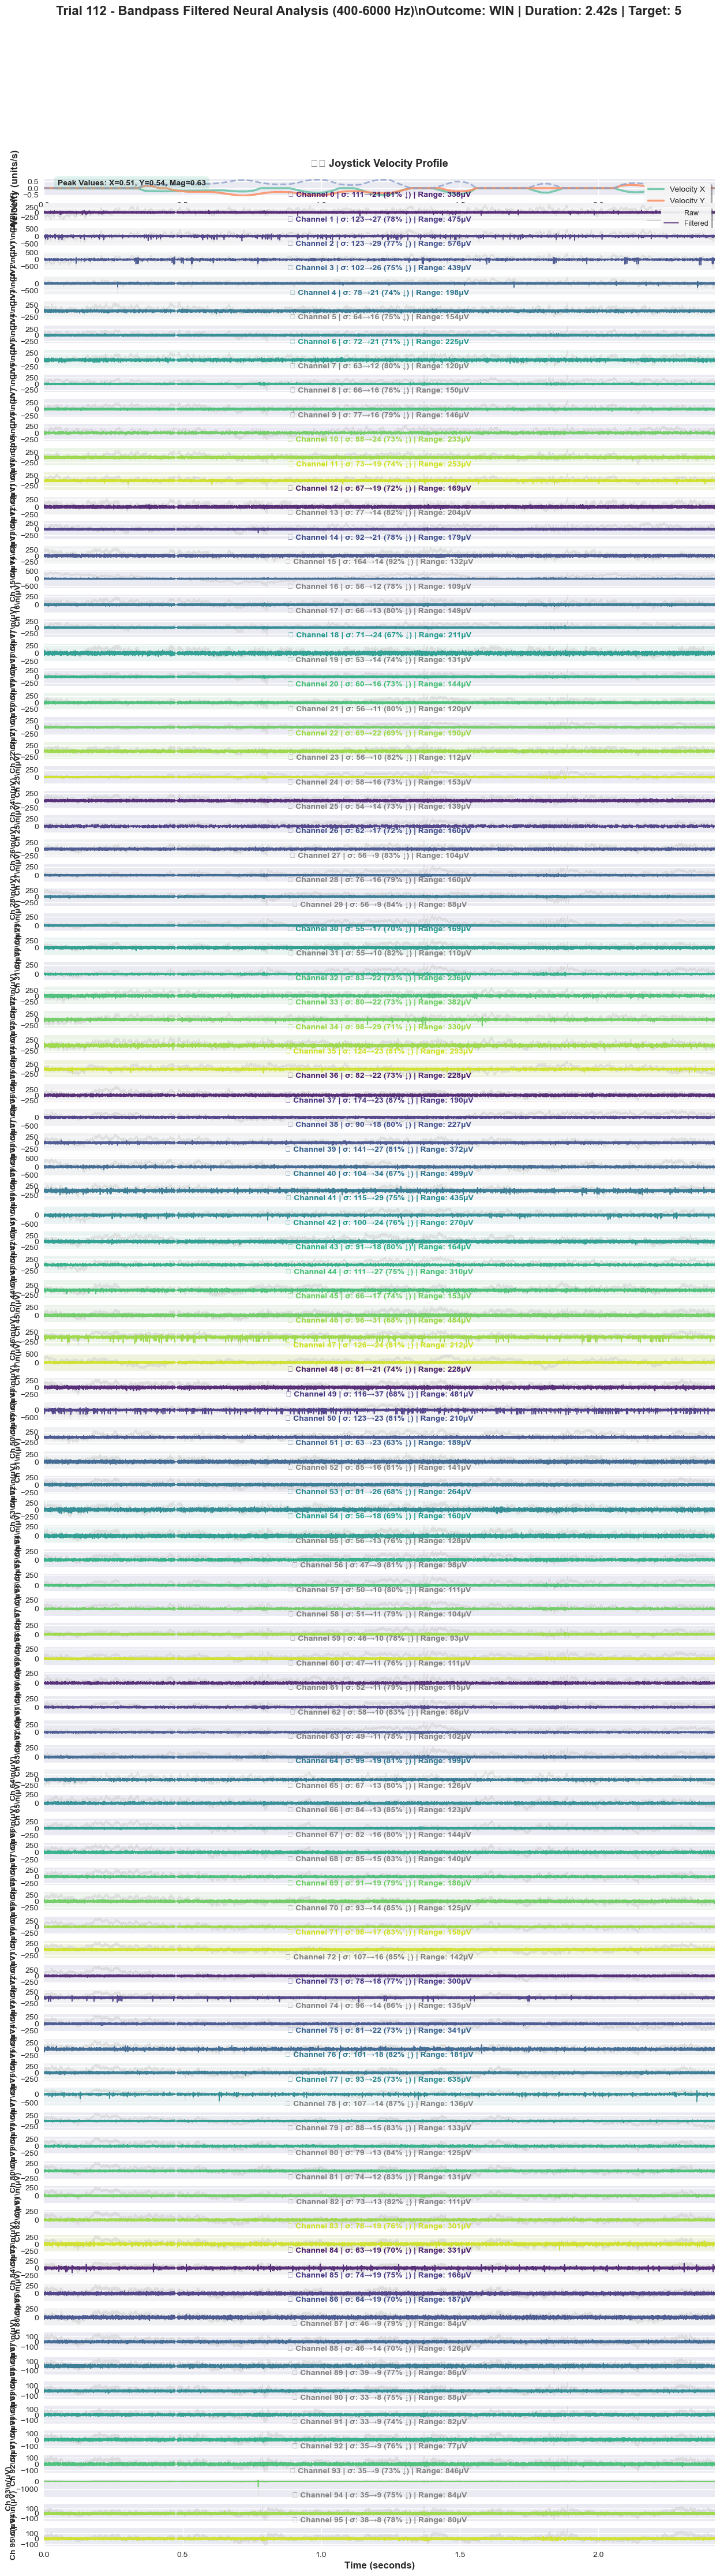

ValueError: 'c' argument has 12 elements, which is inconsistent with 'x' and 'y' with size 96.

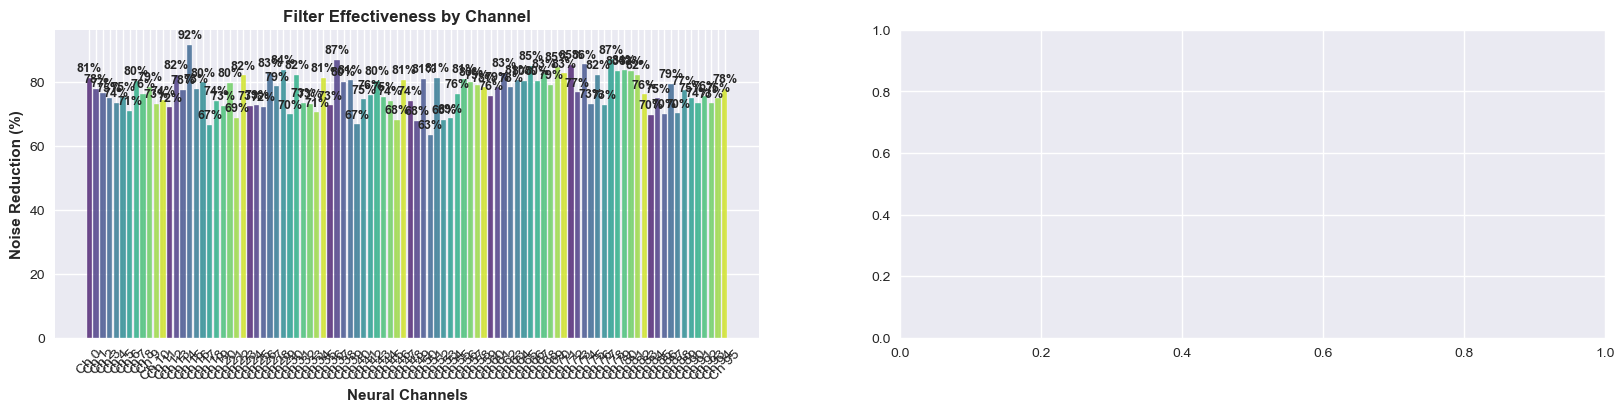

In [ ]:
# Create synchronized visualization with bandpass filtering
if 'trial_data' in locals() and trial_data is not None:
    print(f"🎨 Creating synchronized visualization for trial {TRIAL_NUMBER}...")
    
    # Extract data
    neural_data = trial_data['neural_data']
    velocity_x = trial_data['velocity_x']
    velocity_y = trial_data['velocity_y']
    behavioral_timestamps = trial_data['behavioral_timestamps']
    
    if neural_data is None:
        print("❌ No neural data found!")
    elif velocity_x is None or velocity_y is None:
        print("❌ No behavioral data found!")
    else:
        print(f"📊 Data shapes:")
        print(f"   Neural: {neural_data.shape} (channels × time)")
        print(f"   Velocity: {velocity_x.shape} samples")
        
        # Apply bandpass filter to neural data
        print(f"🔧 Applying bandpass filter ({FILTER_LOW}-{FILTER_HIGH} Hz)...")
        filtered_neural = bandpass_filter(neural_data, FILTER_LOW, FILTER_HIGH, SAMPLING_RATE, FILTER_ORDER)
        
        # Create time axes
        neural_samples = neural_data.shape[1]
        neural_time = np.linspace(0, trial_data['duration'], neural_samples)
        
        # Convert behavioral timestamps to relative time
        if behavioral_timestamps is not None and len(behavioral_timestamps) > 0:
            behavioral_time = behavioral_timestamps - behavioral_timestamps[0]
        else:
            behavioral_time = np.linspace(0, trial_data['duration'], len(velocity_x))
        
        # Select channels for visualization
        if USE_SPIKE_CHANNELS_ONLY:
            # Use only manually identified spike channels
            available_spike_channels = [ch for ch in SPIKE_CHANNELS if ch < neural_data.shape[0]]
            selected_channels = np.array(available_spike_channels)
            n_channels_to_plot = len(selected_channels)
            print(f"Using {n_channels_to_plot} spike channels: {selected_channels}")
        else:
            # Use random channel selection
            np.random.seed(RANDOM_SEED)
            n_channels_to_plot = min(N_CHANNELS, neural_data.shape[0])
            selected_channels = np.random.choice(neural_data.shape[0], n_channels_to_plot, replace=False)
            selected_channels = np.sort(selected_channels)
            print(f"Using {n_channels_to_plot} random channels: {selected_channels}")
        
        print(f"🧠 Selected channels: {selected_channels}")
        print(f"⏱️  Time alignment: Neural {neural_time[-1]:.2f}s, Behavioral {behavioral_time[-1]:.2f}s")
        
        # Calculate dynamic figure size based on number of channels being plotted
        figure_size = calculate_figure_size(n_channels_to_plot)
        print(f"📏 Creating figure with size: {figure_size} for {n_channels_to_plot} channels")
        
        # Create the figure with seaborn styling
        fig = plt.figure(figsize=figure_size, facecolor='white')
        gs = fig.add_gridspec(n_channels_to_plot + 1, 1, hspace=0.4, top=0.90, bottom=0.08)
        
        # Enhanced title with better formatting
        outcome_color = BEHAVIORAL_COLORS[0] if trial_data["outcome"] == "win" else BEHAVIORAL_COLORS[1]
        fig.suptitle(f'Trial {TRIAL_NUMBER} - Bandpass Filtered Neural Analysis ({FILTER_LOW}-{FILTER_HIGH} Hz)\\n'
                     f'Outcome: {trial_data["outcome"].upper()} | Duration: {trial_data["duration"]:.2f}s | '
                     f'Target: {trial_data.get("target_index", "N/A")}', 
                     fontsize=16, fontweight='bold', y=0.96)
        
        # Plot behavioral velocity (top subplot) with enhanced styling
        ax_behavior = fig.add_subplot(gs[0])
        
        # Plot velocity components with seaborn colors
        ax_behavior.plot(behavioral_time, velocity_x, color=BEHAVIORAL_COLORS[0], 
                        linewidth=2.5, label='Velocity X', alpha=0.85)
        ax_behavior.plot(behavioral_time, velocity_y, color=BEHAVIORAL_COLORS[1], 
                        linewidth=2.5, label='Velocity Y', alpha=0.85)
        
        # Calculate and plot velocity magnitude
        velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
        ax_behavior.plot(behavioral_time, velocity_magnitude, color=BEHAVIORAL_COLORS[2], 
                        linewidth=2.0, linestyle='--', label='Magnitude', alpha=0.8)
        
        # Style the behavioral plot
        ax_behavior.set_ylabel('Velocity (units/s)', fontweight='bold', fontsize=12)
        ax_behavior.set_title('🕹️ Joystick Velocity Profile', fontweight='bold', pad=15, fontsize=13)
        
        # Enhanced legend
        legend = ax_behavior.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=10)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_alpha(0.9)
        
        ax_behavior.set_xlim(0, max(neural_time[-1], behavioral_time[-1]))
        sns.despine(ax=ax_behavior, top=True, right=True)
        
        # Enhanced statistics box
        vel_stats = f'Peak Values: X={np.max(np.abs(velocity_x)):.2f}, Y={np.max(np.abs(velocity_y)):.2f}, Mag={np.max(velocity_magnitude):.2f}'
        ax_behavior.text(0.02, 0.95, vel_stats, transform=ax_behavior.transAxes, 
                        bbox=dict(boxstyle="round,pad=0.4", facecolor=BEHAVIORAL_COLORS[0], alpha=0.2, edgecolor=BEHAVIORAL_COLORS[0]),
                        fontsize=10, verticalalignment='top', fontweight='bold')
        
        # Calculate activity levels for color coding
        filt_stds = [np.std(filtered_neural[ch, :]) for ch in selected_channels]
        activity_threshold = np.median(filt_stds)
        
        # Plot filtered neural recordings with enhanced styling
        for i, channel_idx in enumerate(selected_channels):
            ax = fig.add_subplot(gs[i + 1])
            
            # Get original and filtered signals
            original_signal = neural_data[channel_idx, :]
            filtered_signal = filtered_neural[channel_idx, :]
            
            # Use different colors for different channels
            neural_color = NEURAL_COLORS[i % len(NEURAL_COLORS)]
            
            # Plot both signals with enhanced styling
            ax.plot(neural_time, original_signal, color=FILTER_COLORS["raw"], 
                   linewidth=0.6, alpha=0.5, label='Raw' if i == 0 else "")
            ax.plot(neural_time, filtered_signal, color=neural_color, 
                   linewidth=1.2, alpha=0.9, label='Filtered' if i == 0 else "")
            
            # Calculate statistics
            orig_std = np.std(original_signal)
            filt_std = np.std(filtered_signal)
            filt_range = np.ptp(filtered_signal)
            reduction_pct = (1 - filt_std/orig_std) * 100
            
            # Enhanced subplot styling
            ax.set_ylabel(f'Ch {channel_idx}\\n(μV)', fontweight='bold', fontsize=10)
            
            # Color-coded title based on activity level
            title_color = neural_color if filt_std > activity_threshold else 'gray'
            activity_indicator = "🔥" if filt_std > activity_threshold else "📊"
            
            ax.set_title(f'{activity_indicator} Channel {channel_idx} | '
                        f'σ: {orig_std:.0f}→{filt_std:.0f} ({reduction_pct:.0f}% ↓) | Range: {filt_range:.0f}μV', 
                        fontsize=10, pad=8, color=title_color, fontweight='bold')
            
            ax.set_xlim(0, max(neural_time[-1], behavioral_time[-1]))
            sns.despine(ax=ax, top=True, right=True)
            
            # Add subtle background coloring for high-activity channels
            if filt_std > activity_threshold:
                ax.set_facecolor(sns.light_palette(neural_color, as_cmap=False)[0])
            
            # Enhanced legend only on first neural plot
            if i == 0:
                legend = ax.legend(loc='upper right', frameon=True, fancybox=True, 
                                 shadow=True, fontsize=9)
                legend.get_frame().set_facecolor('white')
                legend.get_frame().set_alpha(0.9)
            
            # Only show x-axis label on bottom subplot
            if i == len(selected_channels) - 1:
                ax.set_xlabel('Time (seconds)', fontweight='bold', fontsize=12)
            else:
                ax.set_xticks([])
        
        # Show the enhanced plot
        plt.show()
        
        # Create a summary statistics plot with dynamic width based on number of channels
        stats_width = max(12, min(n_channels_to_plot * 0.8 + 8, 20))  # Scale with channels, 12-20" range
        stats_height = 4
        fig_stats, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(stats_width, stats_height))
        
        # Bar plot of filter effectiveness per channel
        channel_names = [f'Ch {ch}' for ch in selected_channels]
        reduction_percentages = []
        for ch in selected_channels:
            orig = np.std(neural_data[ch, :])
            filt = np.std(filtered_neural[ch, :])
            reduction_percentages.append((1 - filt/orig) * 100)
        
        bars = ax_bar.bar(channel_names, reduction_percentages, 
                         color=NEURAL_COLORS[:len(selected_channels)], alpha=0.8)
        ax_bar.set_title('Filter Effectiveness by Channel', fontweight='bold', fontsize=12)
        ax_bar.set_ylabel('Noise Reduction (%)', fontweight='bold')
        ax_bar.set_xlabel('Neural Channels', fontweight='bold')
        ax_bar.tick_params(axis='x', rotation=45)
        sns.despine(ax=ax_bar, top=True, right=True)
        
        # Add value labels on bars
        for bar, val in zip(bars, reduction_percentages):
            ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                       f'{val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # Scatter plot of behavioral activity vs neural activity
        neural_activity = [np.std(filtered_neural[ch, :]) for ch in selected_channels]
        behavioral_activity_levels = np.ones(len(selected_channels)) * np.max(velocity_magnitude)
        
        scatter = ax_scatter.scatter(neural_activity, behavioral_activity_levels, 
                                   c=NEURAL_COLORS[:len(selected_channels)], 
                                   s=100, alpha=0.7, edgecolors='black', linewidth=1)
        
        ax_scatter.set_xlabel('Neural Activity (Filtered σ)', fontweight='bold')
        ax_scatter.set_ylabel('Peak Behavioral Velocity', fontweight='bold')
        ax_scatter.set_title('Neural vs Behavioral Activity', fontweight='bold', fontsize=12)
        sns.despine(ax=ax_scatter, top=True, right=True)
        
        # Add channel labels to scatter points
        for i, ch in enumerate(selected_channels):
            ax_scatter.annotate(f'Ch{ch}', (neural_activity[i], behavioral_activity_levels[i]),
                              xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
        
        plt.tight_layout()
        plt.show()
        
        # Enhanced summary statistics with formatting
        print("\\n" + "="*80)
        print(f"📊 TRIAL {TRIAL_NUMBER} COMPREHENSIVE ANALYSIS SUMMARY")
        print("="*80)
        
        print(f"\\n🕹️  BEHAVIORAL PERFORMANCE:")
        print(f"   • Velocity X: μ={np.mean(velocity_x):6.3f} ± σ={np.std(velocity_x):5.3f} | Peak: {np.max(np.abs(velocity_x)):5.3f}")
        print(f"   • Velocity Y: μ={np.mean(velocity_y):6.3f} ± σ={np.std(velocity_y):5.3f} | Peak: {np.max(np.abs(velocity_y)):5.3f}")
        print(f"   • Magnitude:  μ={np.mean(velocity_magnitude):6.3f} ± σ={np.std(velocity_magnitude):5.3f} | Peak: {np.max(velocity_magnitude):5.3f}")
        
        # Calculate movement metrics
        movement_duration = np.sum(velocity_magnitude > 0.01) / len(velocity_magnitude) * trial_data['duration']
        stillness_pct = (1 - movement_duration / trial_data['duration']) * 100
        
        print(f"   • Movement time: {movement_duration:.2f}s ({100-stillness_pct:.1f}% of trial)")
        print(f"   • Stillness time: {trial_data['duration']-movement_duration:.2f}s ({stillness_pct:.1f}% of trial)")
        
        print(f"\\n🧠 NEURAL ACTIVITY ANALYSIS (Filtered {FILTER_LOW}-{FILTER_HIGH} Hz):")
        print(f"   {'Channel':<8} {'Raw σ':<8} {'Filt σ':<8} {'Reduction':<10} {'Activity':<10} {'Status'}")
        print(f"   {'-'*8} {'-'*8} {'-'*8} {'-'*10} {'-'*10} {'-'*10}")
        
        total_reduction = 0
        high_activity_count = 0
        
        for ch in selected_channels:
            orig_signal = neural_data[ch, :]
            filt_signal = filtered_neural[ch, :]
            orig_std = np.std(orig_signal)
            filt_std = np.std(filt_signal)
            reduction_pct = (1 - filt_std/orig_std) * 100
            total_reduction += reduction_pct
            
            # Activity classification
            if filt_std > activity_threshold:
                activity_status = "🔥 HIGH"
                high_activity_count += 1
            else:
                activity_status = "📊 MOD"
            
            status_emoji = "✅" if 20 <= reduction_pct <= 80 else "⚠️"
            
            print(f"   Ch {ch:2d}     {orig_std:6.1f}   {filt_std:6.1f}   {reduction_pct:6.1f}%    {activity_status}    {status_emoji}")
        
        avg_reduction = total_reduction / len(selected_channels)
        
        print(f"\\n📈 SUMMARY METRICS:")
        print(f"   • Average noise reduction: {avg_reduction:.1f}%")
        print(f"   • High-activity channels: {high_activity_count}/{len(selected_channels)} ({high_activity_count/len(selected_channels)*100:.1f}%)")
        print(f"   • Filter frequency range: {FILTER_LOW}-{FILTER_HIGH} Hz ({FILTER_HIGH-FILTER_LOW} Hz bandwidth)")
        
        print(f"\\n⚡ QUALITY ASSESSMENT:")
        time_diff = abs(neural_time[-1] - behavioral_time[-1])
        time_status = "✅ EXCELLENT" if time_diff < 0.5 else "✅ GOOD" if time_diff < 1.0 else "⚠️ NEEDS CHECK"
        
        filter_effectiveness = avg_reduction
        filter_status = "✅ EXCELLENT" if filter_effectiveness > 50 else "✅ GOOD" if filter_effectiveness > 30 else "⚠️ MODERATE"
        
        behavioral_activity = np.max(velocity_magnitude)
        activity_status = "✅ VERY ACTIVE" if behavioral_activity > 0.5 else "✅ ACTIVE" if behavioral_activity > 0.1 else "⚠️ LOW ACTIVITY"
        
        print(f"   • Time alignment:     {time_status:<15} (Δt = {time_diff:.3f}s)")
        print(f"   • Filter performance: {filter_status:<15} ({avg_reduction:.1f}% noise reduction)")
        print(f"   • Behavioral activity: {activity_status:<15} (peak = {behavioral_activity:.3f})")
        print(f"   • Data completeness:  {'✅ COMPLETE':<15} (Neural: {neural_data.shape[1]} samples, Behavioral: {len(velocity_x)} samples)")
        
        print("\\n" + "="*80)

else:
    print("❌ No trial data available for visualization!")